<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/NLP9~_Tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
text= [["the"], ["NLP"], ["cv"]]

In [ ]:
encoder = OneHotEncoder(sparse_output=False)

In [ ]:
encoded_words=encoder.fit_transform(text)
encoded_words

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
text=["This is NLP class", "NLP is easy"]
ev = cv.fit_transform(text)
ev.toarray()

array([[1, 0, 1, 1, 1],
       [0, 1, 1, 1, 0]])

In [ ]:
# unigrams = Bag of words
cv1 = CountVectorizer(ngram_range=(1,1))
cv2 = CountVectorizer(ngram_range=(2,2))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
en = tfidf.fit_transform(text)
en.toarray()

array([[0.57615236, 0.        , 0.40993715, 0.40993715, 0.57615236],
       [0.        , 0.70490949, 0.50154891, 0.50154891, 0.        ]])

In [ ]:
import pandas as pd

In [ ]:
df1=pd.read_csv("/content/True.csv", engine='python', encoding='utf-8', on_bad_lines='skip')

In [ ]:
df2 = pd.read_csv("/content/Fake.csv", engine='python', encoding='utf-8', on_bad_lines='skip')

In [ ]:
df1["label"]=1

In [ ]:
df2["label"]=0

In [ ]:
df=pd.concat([df1,df2],axis=0)

In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
df.drop(columns=['subject', 'date'],inplace=True)

In [ ]:
df["new_text"]=df["title"] +" " + df["text"]

In [ ]:
df.columns

Index(['title', 'text', 'label', 'new_text'], dtype='object')

In [ ]:
df.head(5)

,title,text,label,new_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1,Trump wants Postal Service to charge 'much mor...


In [ ]:
df=df.sample(frac=1).reset_index(drop=True)

In [ ]:
x=df.drop(columns=["label"])

In [ ]:
y=df["label"]

In [ ]:
x.shape

(7639, 3)

In [ ]:
y.shape

(7639,)

In [ ]:
x_new=df["new_text"]

In [ ]:
x_new.shape

(7639,)

In [ ]:
import re
def remove_html_tags(text):
  pattern = "<.*?>"
  clean_text = re.sub(pattern, "", text)
  return clean_text

In [ ]:
df["new_text"] = df["new_text"] .apply(remove_html_tags)

In [ ]:

df.columns

Index(['title', 'text', 'label', 'new_text'], dtype='object')

In [ ]:
df.head()

,title,text,label,new_text
0,The ‘Fake Melania Trump’ Conspiracy Theory Is...,"The Internet is going crazy after photos, vide...",0,The ‘Fake Melania Trump’ Conspiracy Theory Is...
1,Trump urges U.S. Congress to repeal Obamacare,WASHINGTON (Reuters) - U.S. President Donald T...,1,Trump urges U.S. Congress to repeal Obamacare ...
2,North Korea says nearly 3.5 million volunteer ...,SEOUL (Reuters) - North Korea said on Saturday...,1,North Korea says nearly 3.5 million volunteer ...
3,Drugmaker shares slip as Trump tweets about pr...,(Reuters) - Shares of U.S. pharmaceutical and ...,1,Drugmaker shares slip as Trump tweets about pr...
4,House Ways and Means Chairman aims to move tax...,WASHINGTON (Reuters) - U.S. House of Represent...,1,House Ways and Means Chairman aims to move tax...


In [ ]:
def remove_newline_character(text):
    pattern = "\n"
    clean_text = re.sub(pattern,"",text)
    return clean_text

In [ ]:

df["new_text"] = df["new_text"] .apply(remove_newline_character)

In [ ]:
import string

In [ ]:
exclude = list(string.punctuation)
exclude

['!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~']

In [ ]:
def remove_punctuation(text):
    for char in exclude:
        if char in text:
            text = text.replace(char,"")
    return text

In [ ]:
df["new_text"] = df["new_text"] .apply(remove_punctuation)

In [ ]:
def remove_space(text):
    pattern = "\s+"
    clean_text = re.sub(pattern," ",text)
    return clean_text

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_739/3883034018.py:2: SyntaxWarning: invalid escape sequence '\s'
  pattern = "\s+"


In [ ]:
df["new_text"] = df["new_text"] .apply(remove_space)

# Exploratory Data Analysis

**Univariate Analysis**

In [ ]:
df.columns

Index(['title', 'text', 'label', 'new_text'], dtype='object')

In [ ]:
df["char_count"]=df["new_text"].str.len()

In [ ]:
df["word_count"]=df["new_text"].str.split().apply(len)

In [ ]:
df.head()

,title,text,label,new_text,char_count,word_count
0,The ‘Fake Melania Trump’ Conspiracy Theory Is...,"The Internet is going crazy after photos, vide...",0,The ‘Fake Melania Trump’ Conspiracy Theory Is...,3520,610
1,Trump urges U.S. Congress to repeal Obamacare,WASHINGTON (Reuters) - U.S. President Donald T...,1,Trump urges US Congress to repeal Obamacare WA...,637,104
2,North Korea says nearly 3.5 million volunteer ...,SEOUL (Reuters) - North Korea said on Saturday...,1,North Korea says nearly 35 million volunteer f...,1316,212
3,Drugmaker shares slip as Trump tweets about pr...,(Reuters) - Shares of U.S. pharmaceutical and ...,1,Drugmaker shares slip as Trump tweets about pr...,3156,520
4,House Ways and Means Chairman aims to move tax...,WASHINGTON (Reuters) - U.S. House of Represent...,1,House Ways and Means Chairman aims to move tax...,808,138


In [ ]:
def count_punctuation(text):
    count = 0
    for char in exclude:
        if char in text:
            count = count+1
    return count

In [ ]:
df["punct_count"]=df["new_text"].apply(count_punctuation)

In [ ]:
df.head()

,title,text,label,new_text,char_count,word_count,punct_count
0,The ‘Fake Melania Trump’ Conspiracy Theory Is...,"The Internet is going crazy after photos, vide...",0,The ‘Fake Melania Trump’ Conspiracy Theory Is...,3520,610,0
1,Trump urges U.S. Congress to repeal Obamacare,WASHINGTON (Reuters) - U.S. President Donald T...,1,Trump urges US Congress to repeal Obamacare WA...,637,104,0
2,North Korea says nearly 3.5 million volunteer ...,SEOUL (Reuters) - North Korea said on Saturday...,1,North Korea says nearly 35 million volunteer f...,1316,212,0
3,Drugmaker shares slip as Trump tweets about pr...,(Reuters) - Shares of U.S. pharmaceutical and ...,1,Drugmaker shares slip as Trump tweets about pr...,3156,520,0
4,House Ways and Means Chairman aims to move tax...,WASHINGTON (Reuters) - U.S. House of Represent...,1,House Ways and Means Chairman aims to move tax...,808,138,0


<Axes: xlabel='label'>

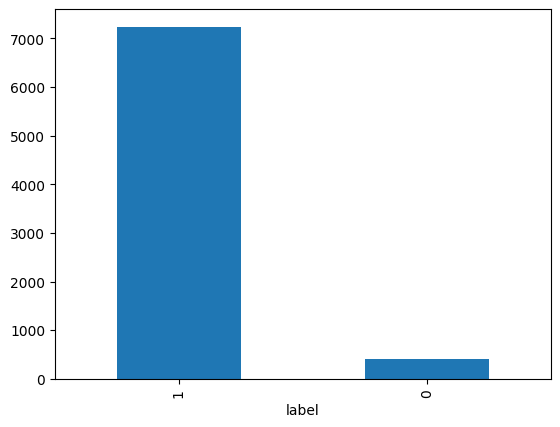

In [ ]:
df["label"].value_counts().plot(kind='bar')

In [ ]:
df["label"].value_counts(normalize = True)

,proportion
label,
1,0.947244
0,0.052756


In [ ]:
fake_char_count = df[df["label"]==0]["char_count"]
true_char_count = df[df["label"]==1]["char_count"]

In [ ]:
#estimate avg char count for spam and ham--->CLT
def estimate_CLT(data,sample_size,no_of_samples):
    mean_lst=[]
    for i in range(no_of_samples):
        smaples=np.random.choice(data,size=sample_size)
        mean_lst.append(np.mean(smaples))
    mean_Array=np.array(mean_lst)
    return np.mean(mean_Array)

In [ ]:
import numpy as np
sample_size=30
no_of_samples=1000
data=fake_char_count
avg_spam_char=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_char

np.float64(2486.044033333333)

In [ ]:
sample_size=30
no_of_samples=1000
data=true_char_count
avg_spam_char=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_char

np.float64(2493.074333333333)

In [ ]:
fake_word_count = df[df["label"]==0]["word_count"]
true_word_count = df[df["label"]==1]["word_count"]

In [ ]:
sample_size=30
no_of_samples=1000
data=fake_word_count
avg_spam_word=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_word

np.float64(427.322)

In [ ]:
sample_size=30
no_of_samples=1000
data=true_word_count
avg_spam_word=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_word

np.float64(402.45930000000004)

In [ ]:
fake_punct_count = df[df["label"]==0]["punct_count"]
true_punct_count = df[df["label"]==1]["punct_count"]

In [ ]:
sample_size=30
no_of_samples=1000
data=fake_punct_count
avg_fake_punct_count=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_fake_punct_count

np.float64(0.0)

In [ ]:
sample_size=30
no_of_samples=1000
data=true_punct_count
avg_true_punct_count=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_true_punct_count

np.float64(0.0)

# Bivariate Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'char_count for spam and ham')

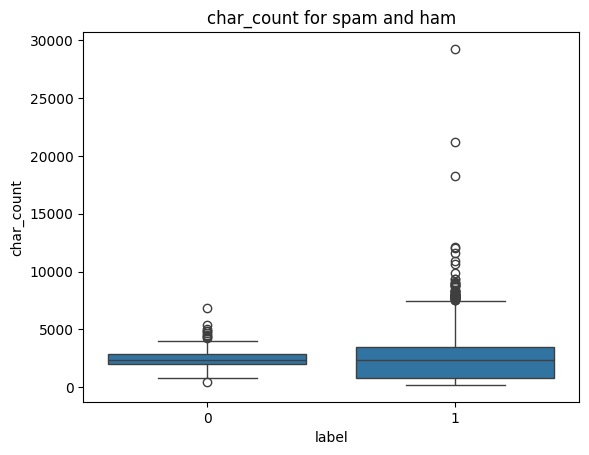

In [ ]:
sns.boxplot(x="label",y="char_count",data=df)
plt.title("char_count for spam and ham")

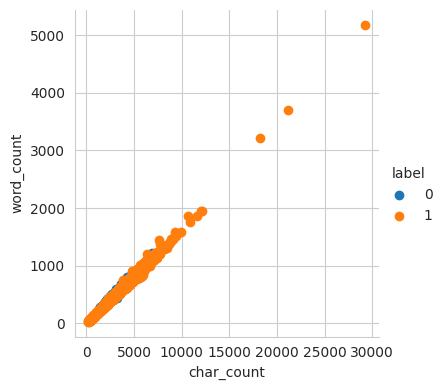

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="label",height=4).map(plt.scatter,"char_count","word_count").add_legend()
plt.show()

Text(0.5, 1.0, 'Feature Correlation Heatmap')

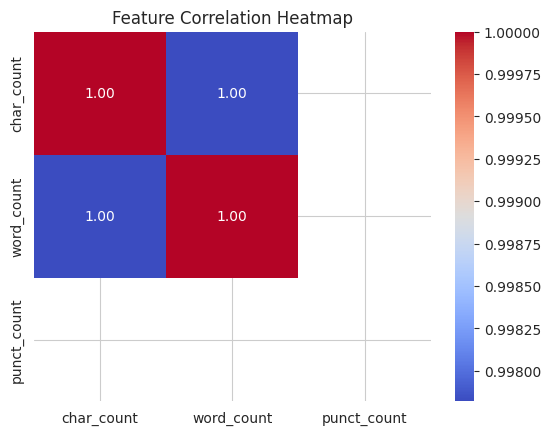

In [ ]:
corr_matrix = df[["char_count","word_count","punct_count"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")

# Multi-Variate Analysis

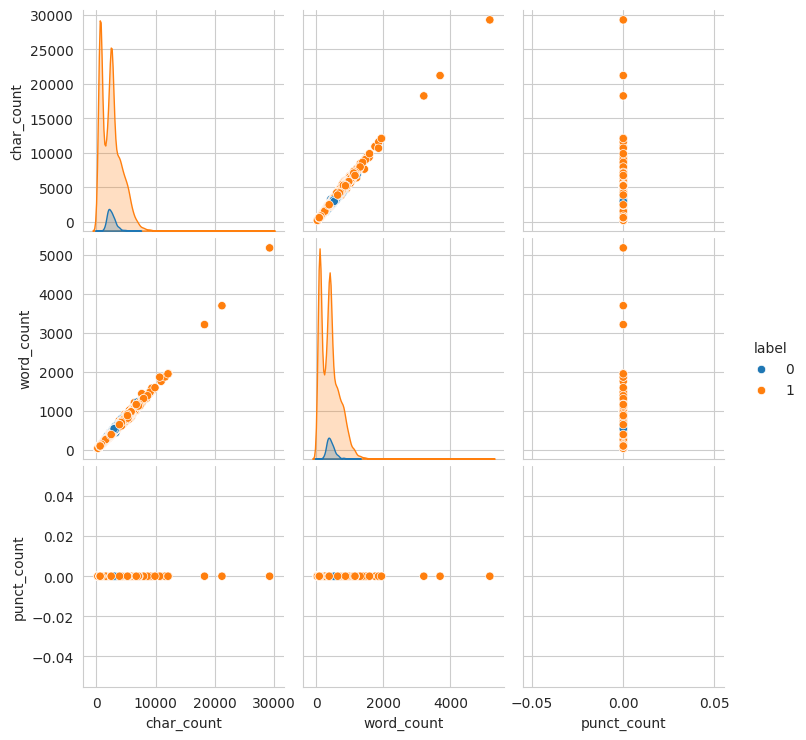

In [ ]:
sns.pairplot(df[["char_count","word_count","punct_count","label"]], hue="label")

In [ ]:
df.columns

Index(['title', 'text', 'label', 'new_text', 'char_count', 'word_count',
       'punct_count'],
      dtype='object')

In [ ]:
x = df.drop(columns=['punct_count', 'char_count', 'word_count','label'])

In [ ]:
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x_new,y,test_size=0.2,random_state=42)

In [ ]:
xtrain.shape

(6111,)

In [ ]:
xtest.shape

(1528,)

In [ ]:
type(xtrain)

pandas.core.series.Series

In [ ]:
type(xtest)

pandas.core.series.Series

In [ ]:
xtrain_convert=xtrain.astype("str").tolist()
xtest_convert=xtest.astype("str").tolist()

In [ ]:
type(xtrain_convert)

list

In [ ]:
type(xtest_convert)

list

# Text Representation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

In [ ]:
xtrain_tfidf=vectorizer.fit_transform(xtrain_convert)

In [ ]:
xtrain_tfidf.shape

(6111, 35816)

In [ ]:
xtest_tfidf=vectorizer.transform(xtest_convert)

In [ ]:
xtest_tfidf.shape

(1528, 35816)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
mnbmodel=MultinomialNB()

In [ ]:
params_grid={
    "alpha":[0.1,0.01,1.0,2.0]
}

In [ ]:
grid=GridSearchCV(
    estimator=mnbmodel,
    param_grid=params_grid,
    cv=5,
    scoring="accuracy"
)

In [ ]:
grid.fit(xtrain_tfidf,ytrain)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.1, 0.01, 1.0, 2.0]}, scoring='accuracy')

In [ ]:
grid.best_params_

{'alpha': 0.01}

In [ ]:
grid.best_score_

np.float64(0.9842901935489051)

In [ ]:
model=MultinomialNB(alpha=0.01)

In [ ]:
model.fit(xtrain_tfidf,ytrain)

MultinomialNB(alpha=0.01)

In [ ]:
ypred=model.predict(xtest_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
accuracy_score(ytest,ypred)

0.9869109947643979

In [ ]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88        91
           1       0.99      1.00      0.99      1437

    accuracy                           0.99      1528
   macro avg       0.97      0.91      0.94      1528
weighted avg       0.99      0.99      0.99      1528



In [ ]:
confusion_matrix(ytest,ypred)

array([[  75,   16],
       [   4, 1433]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model1=LogisticRegression(max_iter=1000)

In [ ]:
params_grid1={
    "C":[1.0,0.1,0.01,2.0],
    "penalty":["l1", "l2", "elasticnet"],
    "solver":["lbfgs","liblinear"]
}

In [ ]:
grid2=GridSearchCV(
    estimator=model1,
    param_grid=params_grid1,
    cv=5,
    scoring="accuracy"
)

In [ ]:
grid2.fit(xtrain_tfidf,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [1.0, 0.1, 0.01, 2.0],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [ ]:
grid2.best_params_

{'C': 2.0, 'penalty': 'l1', 'solver': 'liblinear'}

In [ ]:
grid2.best_score_

np.float64(0.9944357533526128)

In [ ]:
lr_model=LogisticRegression(C=2.0,penalty="l1",solver="liblinear",max_iter=1000)

In [ ]:
lr_model.fit(xtrain_tfidf,ytrain)

LogisticRegression(C=2.0, max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
ypred1=lr_model.predict(xtest_tfidf)

In [ ]:
accuracy_score(ytest,ypred1)

0.9960732984293194

In [ ]:
print(classification_report(ytest,ypred1))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        91
           1       1.00      1.00      1.00      1437

    accuracy                           1.00      1528
   macro avg       1.00      0.97      0.98      1528
weighted avg       1.00      1.00      1.00      1528



In [ ]:
confusion_matrix(ytest,ypred1)

array([[  85,    6],
       [   0, 1437]])